# 🐶🐱 Cats vs Dogs Classification – Complete Teaching Demo
## HOG vs CNN Features + SVM + Visualizations

This notebook demonstrates:
- HOG feature extraction + visualization
- CNN (ResNet18) feature extraction
- Grad-CAM visualization
- Saving features to CSV
- SVM training
- Confusion matrix
- ROC curve
- Performance comparison

# Cats vs Dogs Classification
## HOG vs CNN Feature Extraction + SVM

**Import Libraries**

In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from skimage.feature import hog

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix, roc_curve, auc

import seaborn as sns
import torch
import torchvision.models as models
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import Subset
from torch.utils.data import DataLoader,Subset
%matplotlib inline

**Load Dataset**

In [2]:
data_dir = "/kaggle/input/datasets/bhavikjikadara/dog-and-cat-classification-dataset/PetImages"

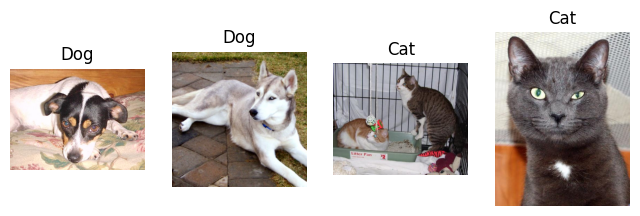

In [3]:
plt.figure(figsize=(8,4))

count=0

for label in os.listdir(data_dir):

    for img in os.listdir(os.path.join(data_dir,label))[:2]:

        path=os.path.join(data_dir,label,img)

        image=cv2.imread(path)

        image=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)

        plt.subplot(1,4,count+1)

        plt.imshow(image)

        plt.title(label)

        plt.axis("off")

        count+=1

plt.show()

 **HOG Feature Extraction** 

Corrupt JPEG data: 239 extraneous bytes before marker 0xd9


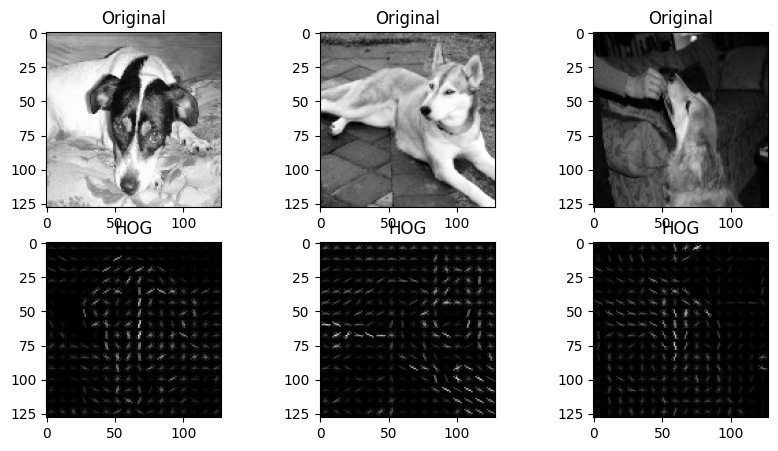

In [4]:
hog_features=[]
hog_labels=[]

plt.figure(figsize=(10,5))

display_count=0

for label in os.listdir(data_dir):

    for file in os.listdir(os.path.join(data_dir,label))[:300]:
        img_path=os.path.join(data_dir,label,file)

        img=cv2.imread(img_path)

        if img is None:
            continue

        img=cv2.resize(img,(128,128))

        gray=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)

        features,hog_img=hog(
            gray,
            orientations=9,
            pixels_per_cell=(8,8),
            cells_per_block=(2,2),
            visualize=True
        )

        hog_features.append(features)
        hog_labels.append(label)

        if display_count<3:

            plt.subplot(2,3,display_count+1)
            plt.imshow(gray,cmap="gray")
            plt.title("Original")

            plt.subplot(2,3,display_count+4)
            plt.imshow(hog_img,cmap="gray")
            plt.title("HOG")

            display_count+=1

plt.show()

**Create Feature Dataset**

In [5]:
hog_df=pd.DataFrame(hog_features)

hog_df["label"]=hog_labels

hog_df.head()

,0,1,2,3,4,5,6,7,8,9,...,8091,8092,8093,8094,8095,8096,8097,8098,8099,label
0,0.032172,0.003128,0.005043,0.197402,0.297989,0.297989,0.198135,0.027982,0.004423,0.067141,...,0.245794,0.245794,0.245794,0.122279,0.222092,0.092706,0.032238,0.150090,0.177779,Dog
1,0.258973,0.086154,0.175565,0.258973,0.258973,0.200007,0.102378,0.084238,0.138475,0.170356,...,0.050591,0.001142,0.000000,0.000000,0.230439,0.200192,0.384770,0.008488,0.018609,Dog
2,0.085412,0.057742,0.038826,0.035720,0.027454,0.000000,0.025884,0.023248,0.050339,0.248583,...,0.293138,0.149463,0.009146,0.000000,0.045270,0.055362,0.023317,0.139327,0.092595,Dog
3,0.384140,0.000000,0.017613,0.008558,0.056215,0.004641,0.011742,0.015020,0.384140,0.263616,...,0.115035,0.118406,0.029423,0.151963,0.161858,0.227872,0.197084,0.116137,0.157705,Dog
4,0.121608,0.063503,0.084918,0.030774,0.050334,0.006109,0.020625,0.008639,0.028177,0.345924,...,0.227361,0.144347,0.097830,0.156758,0.227361,0.227361,0.141485,0.095892,0.109964,Dog


**Train SVM on HOG Features**

In [6]:
X=hog_df.drop("label",axis=1).values
y=hog_df["label"].values

X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y
)

scaler=StandardScaler()

X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

svm=SVC(kernel="linear",probability=True)

svm.fit(X_train,y_train)

y_pred=svm.predict(X_test)

print("Accuracy:",accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuracy: 0.675
              precision    recall  f1-score   support

         Cat       0.71      0.58      0.64        60
         Dog       0.65      0.77      0.70        60

    accuracy                           0.68       120
   macro avg       0.68      0.68      0.67       120
weighted avg       0.68      0.68      0.67       120



**Confusion Matrix**

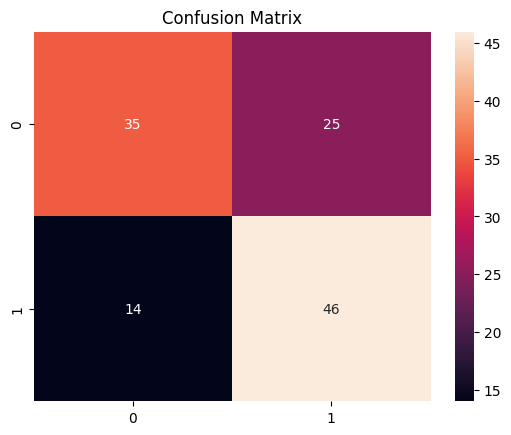

In [7]:
cm=confusion_matrix(y_test,y_pred)

sns.heatmap(cm,annot=True,fmt="d")

plt.title("Confusion Matrix")

plt.show()

**ROC Curve**

**CNN Feature Extraction**

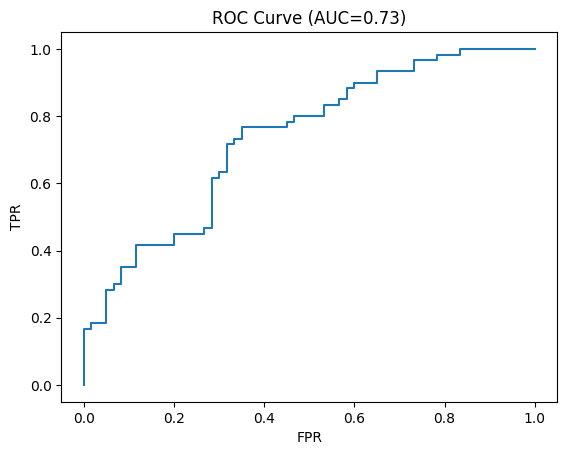

In [8]:
y_prob=svm.predict_proba(X_test)[:,1]

fpr,tpr,_=roc_curve((y_test=="Dog").astype(int),y_prob)

roc_auc=auc(fpr,tpr)

plt.plot(fpr,tpr)

plt.title(f"ROC Curve (AUC={roc_auc:.2f})")

plt.xlabel("FPR")

plt.ylabel("TPR")

plt.show()

**CNN Feature SVM**

In [9]:
from torchvision.models import resnet18

# model
model = resnet18(weights=None)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()

# transform
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor()
])

# dataset load
dataset = ImageFolder(data_dir, transform=transform)

# sirf 500 images use karega
indices = np.random.choice(len(dataset), 500, replace=False)
dataset = Subset(dataset, indices)

# dataloader
loader = DataLoader(dataset, batch_size=32, shuffle=True)

In [10]:
# feature extraction
cnn_features=[]
cnn_labels=[]

with torch.no_grad():

    for imgs,lbls in loader:

        output=model(imgs)

        output=output.view(output.size(0),-1)

        cnn_features.append(output.numpy())

        cnn_labels.append(lbls.numpy())

X_cnn=np.vstack(cnn_features)
y_cnn=np.hstack(cnn_labels)

X_train_cnn,X_test_cnn,y_train_cnn,y_test_cnn=train_test_split(
    X_cnn,y_cnn,test_size=0.2,random_state=42
)

svm_cnn=SVC(kernel="linear")

svm_cnn.fit(X_train_cnn,y_train_cnn)

y_pred_cnn=svm_cnn.predict(X_test_cnn)

print("CNN Accuracy:",accuracy_score(y_test_cnn,y_pred_cnn))

CNN Accuracy: 0.68


**Performance Comparison**

In [11]:
print("HOG Accuracy:",accuracy_score(y_test,y_pred))
print("CNN Accuracy:",accuracy_score(y_test_cnn,y_pred_cnn))

HOG Accuracy: 0.675
CNN Accuracy: 0.68
